# Lecture 9: Agentic Evaluation

### 1. 기존 소프트웨어와의 차이
기존 소프트웨어 테스트는 정해진 입력에 정해진 출력이 나오는 **'결정론적(Deterministic)'** 세계였습니다. 하지만 에이전트는 다릅니다.

* **비결정론적 프로세스:** 같은 질문에도 매번 다른 답변이 나올 수 있습니다.
* **의미 맥락(Semantic Context):** 에이전트는 고정된 로직이 아니라 '의미와 맥락'을 부품 삼아 스스로 의사결정을 내립니다.

따라서 에이전트의 평가는 단순히 버그를 찾는 과정이 아니라, **변동성 속에서 위험을 관리(Managing Risk)하는 과정**이 되어야 합니다.

### 2. 평가 데이터셋: 위험 관리의 첫 단추
위험 관리를 시작하는 가장 확실한 방법은 **평가 데이터셋(Evaluation Dataset)**을 구축하는 것입니다.

> **"완벽한 출력을 정의하기는 어렵지만, 우리가 허용할 수 있는 '품질의 범위'는 정의할 수 있습니다."**

많은 엔지니어들이 수많은 엣지 케이스(Edge Case)를 모두 커버해야 한다는 압박감에 평가 데이터셋 구축을 어려워합니다. 하지만 기억하세요. 평가는 한 번에 끝나는 것이 아니라 **반복적인 과정**입니다.


### 3. 시작은 가볍게, 과정은 견고하게
처음부터 1,000개의 데이터가 필요하지 않습니다. 오늘 우리가 실습할 **10~20개의 예시**만으로도 충분합니다.

* **기준의 수립:** 작은 데이터셋이라도 우리 서비스의 '기준'이 됩니다.
* **점진적 개선:** 시간이 지나며 데이터가 쌓이고, 평가는 자연스럽게 보완됩니다.

평가는 항상 **반복적인 과정**이며, 조금씩 나아가는 과정임을 염두에 두고 오늘의 실습을 진행해 보겠습니다. 🚀

## 환경 설정

- 실습 환경 구축을 위한 패키지 설치 (설치 후 세션을 다시 시작해야합니다.)

In [1]:
!pip install langgraph langchain-upstage langchain==1.1.3 \
     rich tavily-python  langchain-text-splitters langchain_classic \
     qdrant_client langchain_qdrant langsmith langchain_tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.2/377.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.8/295.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 34.3 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.3
    Uninstalling langchain-1.2.3:
      Successfully uninstalled langchain-1.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.57

- Google Colab의 '보안 비밀번호(Secrets)' 메뉴에 등록한 API KEY를 환경 변수로 불러옵니다.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

# 설정할 키 목록
keys = [
    'LANGSMITH_API_KEY', 'UPSTAGE_API_KEY', 'TAVILY_API_KEY'
]

for key in keys:
    value = os.getenv(key)
    if value is None:
        print(f"경고: {key}를 .env에서 찾을 수 없습니다.")
    else:
        os.environ[key] = value

# 고정값 설정
os.environ["LANGSMITH_TRACING_V2"] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = 'agentic-workflow'

- 실습에 필요한 라이브러리 로드 및 LLM 모델 초기화

In [3]:
from rich import print as rprint
from langchain.chat_models import init_chat_model

MODEL = "solar-pro2"
llm = init_chat_model(
    model=MODEL,
    temperature=0.1
)

## LangSmith
- **소개**
    - LangChain 팀이 만든, LLM 애플리케이션 전용 “Observability + Evaluation” 플랫폼
    - 세션/체인/에이전트의 실행을 모두 기록하고, 이를 바탕으로 데이터셋·실험·평가를 돌려 품질을 지속적으로 개선하는 도구.
- **핵심 기능**
    - 추적·로깅
    - 평가
    - 데이터셋 관리
    - 실험·프로덕션 모니터링

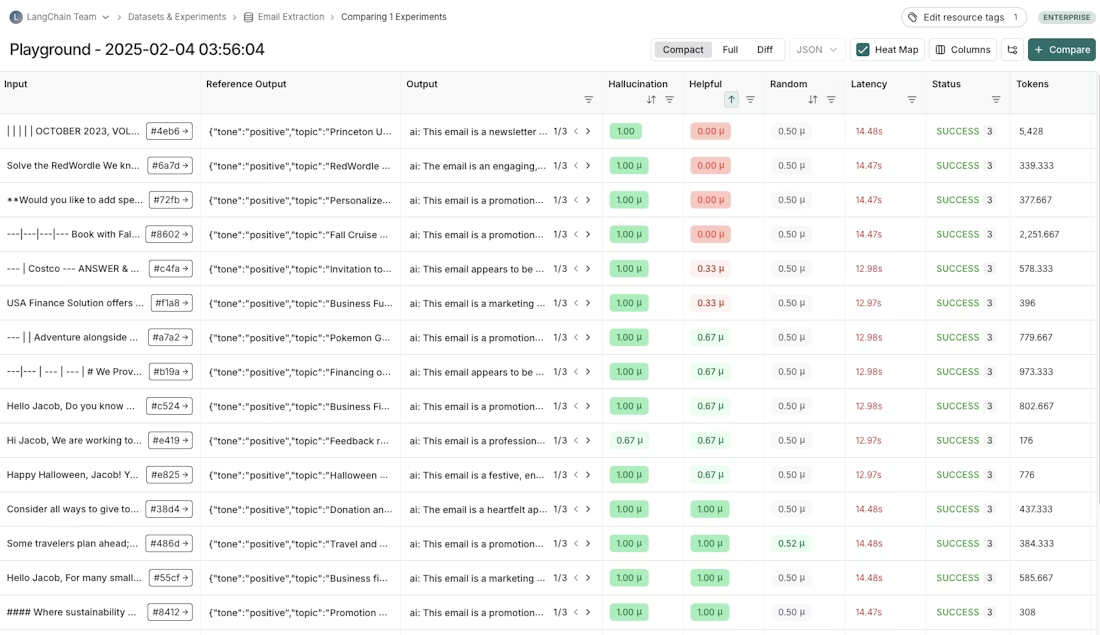

## Evaluate Chat
- 참고자료: https://docs.langchain.com/langsmith/evaluate-chatbot-tutorial.

### Create Dataset

In [4]:
from langsmith import Client

client = Client()

# 1. 데이터셋 이름 설정
dataset_name = "AgentOps & Evaluation Whitepaper Q&A"

# 2. 데이터셋 존재 여부 확인 후 생성
if not client.has_dataset(dataset_name=dataset_name):
    # 데이터셋 생성
    dataset = client.create_dataset(
        dataset_name=dataset_name,
        description="Google 백서 기반 AgentOps 및 평가 방법론 데이터셋"
    )

    # 평가용 예시 데이터 정의
    examples = [
        {
            "inputs": {"question": "AgentOps의 핵심 구성 요소 중 '관측성(Observability)'이 중요한 이유는 무엇인가요?"},
            "outputs": {"answer": "에이전트의 복잡한 사고 과정(Reasoning)과 도구 호출(Tool Calling) 과정을 추적하여 병목 현상을 진단하고, 환각 발생 시점을 파악하기 위해 필수적입니다."}
        },
        {
            "inputs": {"question": "LLM-as-a-Judge 방법론을 사용할 때 발생할 수 있는 '바이어스'의 예시는?"},
            "outputs": {"answer": "위치 바이어스(Position bias), 길이 바이어스(Verbosity bias), 모델 자아 바이어스(Self-enhancement bias) 등이 있습니다."}
        },
        {
            "inputs": {"question": "에이전트 평가에서 'Faithfulness(성실성)' 지표의 정의는?"},
            "outputs": {"answer": "생성된 답변이 주어진 검색 결과(Context)에만 근거하여 작성되었는지 측정하는 지표입니다."}
        },
        {
            "inputs": {"question": "Human-in-the-loop(HITL) 평가가 자동 평가보다 우수한 점은?"},
            "outputs": {"answer": "주관적인 품질(톤, 안전성) 검증과 자동 평가기의 기준이 되는 고품질의 레이블(Ground Truth)을 제공할 수 있다는 점입니다."}
        },
        {
            "inputs": {"question": "실행 경로(Execution Path) 평가가 결과값 평가보다 중요한 이유는?"},
            "outputs": {"answer": "정답을 맞혔더라도 비효율적인 추론이나 잘못된 도구 사용을 거쳤다면 운영 비용과 지연 시간이 증가하기 때문입니다."}
        }
    ]

    # 데이터셋에 예시 추가
    client.create_examples(
        dataset_id=dataset.id,
        examples=examples
    )
    print(f"✅ 데이터셋 '{dataset_name}' 생성이 완료되었습니다.")
else:
    print(f"ℹ️ '{dataset_name}' 데이터셋이 이미 존재합니다. (생성 생략)")

ℹ️ 'AgentOps & Evaluation Whitepaper Q&A' 데이터셋이 이미 존재합니다. (생성 생략)


### Define Metrics

In [5]:
from pydantic import BaseModel, Field
from typing import Literal
from langsmith import wrappers

class Grade(BaseModel):
    """학생의 답변을 채점한 결과입니다."""
    # 결과값을 bool 타입으로 직접 받거나 CORRECT/INCORRECT로 제한할 수 있습니다.
    score: Literal["CORRECT", "INCORRECT"] = Field(description="답변이 정답과 일치하면 'CORRECT', 틀리면 'INCORRECT'")
    reason: str = Field(description="채점 결과에 대한 이유")

# 기대 출력이 올바른지 확인
def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    structured_llm = llm.with_structured_output(Grade)

    user_content = f"""You are grading the following question:
{inputs['question']}
Here is the real answer:
{reference_outputs['answer']}
You are grading the following predicted answer:
{outputs['answer']}"""

    eval_instructions = "You are an expert professor specialized\
 in grading students' answers to questions."

    response = structured_llm.invoke([
        {"role": "system", "content": eval_instructions},
        {"role": "user", "content": user_content},
    ])

    return response.score == "CORRECT"

# 답변 길이 평가
def concision(outputs: dict, reference_outputs: dict) -> bool:
    return int(len(outputs["answer"]) < 2 * len(reference_outputs["answer"]))

### Run Evaluator

In [6]:
from pydantic import BaseModel, Field

class AppOutput(BaseModel):
    answer: str = Field(description="사용자의 질문에 대한 최종 답변")
    reasoning: str = Field(description="답변을 도출한 사고 과정")

def my_app(question: str) -> str:
    default_instructions = "Respond to the users question in a short, concise manner (one short sentence)."

    structured_llm = llm.with_structured_output(AppOutput)

    response = structured_llm.invoke([
        {"role": "system", "content": default_instructions},
        {"role": "user", "content": question},
    ])

    return response

In [7]:
def ls_target(inputs: dict) -> dict:
    result = my_app(inputs["question"])

    # LangSmith 기록을 위해 딕셔너리로 변환
    return result.model_dump()

In [8]:
experiment_results = client.evaluate(
    ls_target, # Your AI system
    data=dataset_name, # The data to predict and grade over
    evaluators=[concision, correctness], # The evaluators to score the results
    experiment_prefix="Evaluate_Chat", # A prefix for your experiment names to easily identify them
)

View the evaluation results for experiment: 'Evaluate_Chat-d559f153' at:
https://smith.langchain.com/o/7eb12019-fc22-4cd9-8caf-766b99514a6f/datasets/5f7326d1-892f-4ba8-8d43-c2c8ff960416/compare?selectedSessions=2fa67225-de0b-47d5-ba60-144c2f1d380d




0it [00:00, ?it/s]

### 평가 점수가 안보인다면

- Display 클릭 > Visible 꺼주기 > Save > 다시 Display 들어와서 > Visible 켜주기 > Save

- Display 클릭

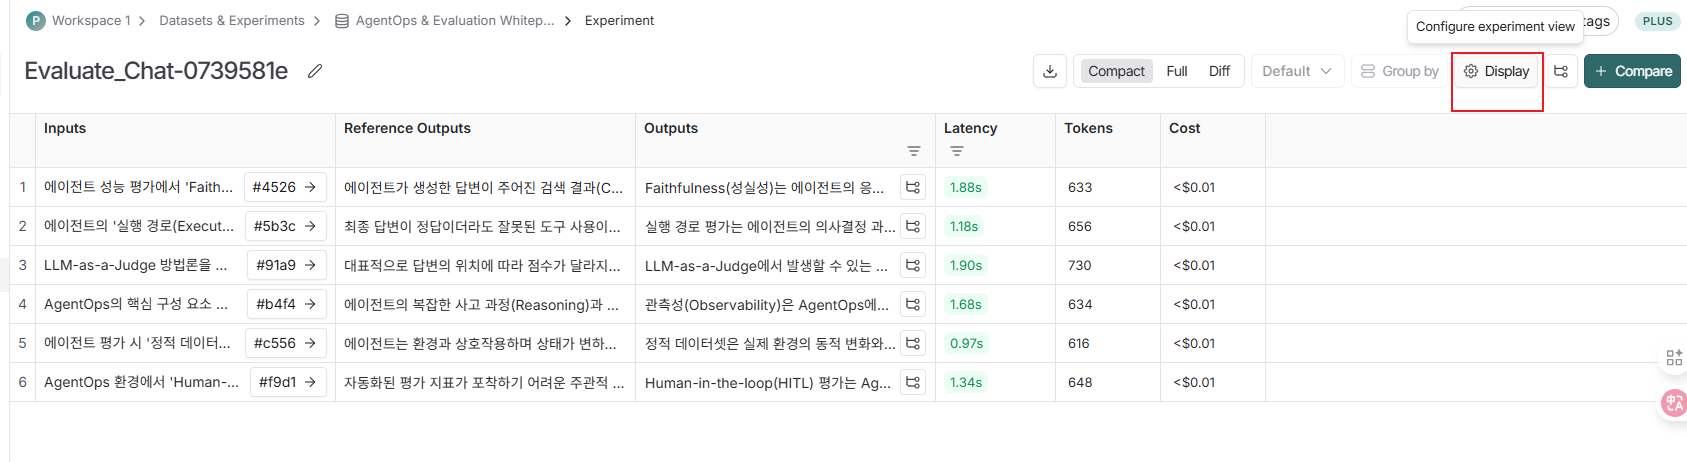

- 정의해준 concision과 correctness 확인

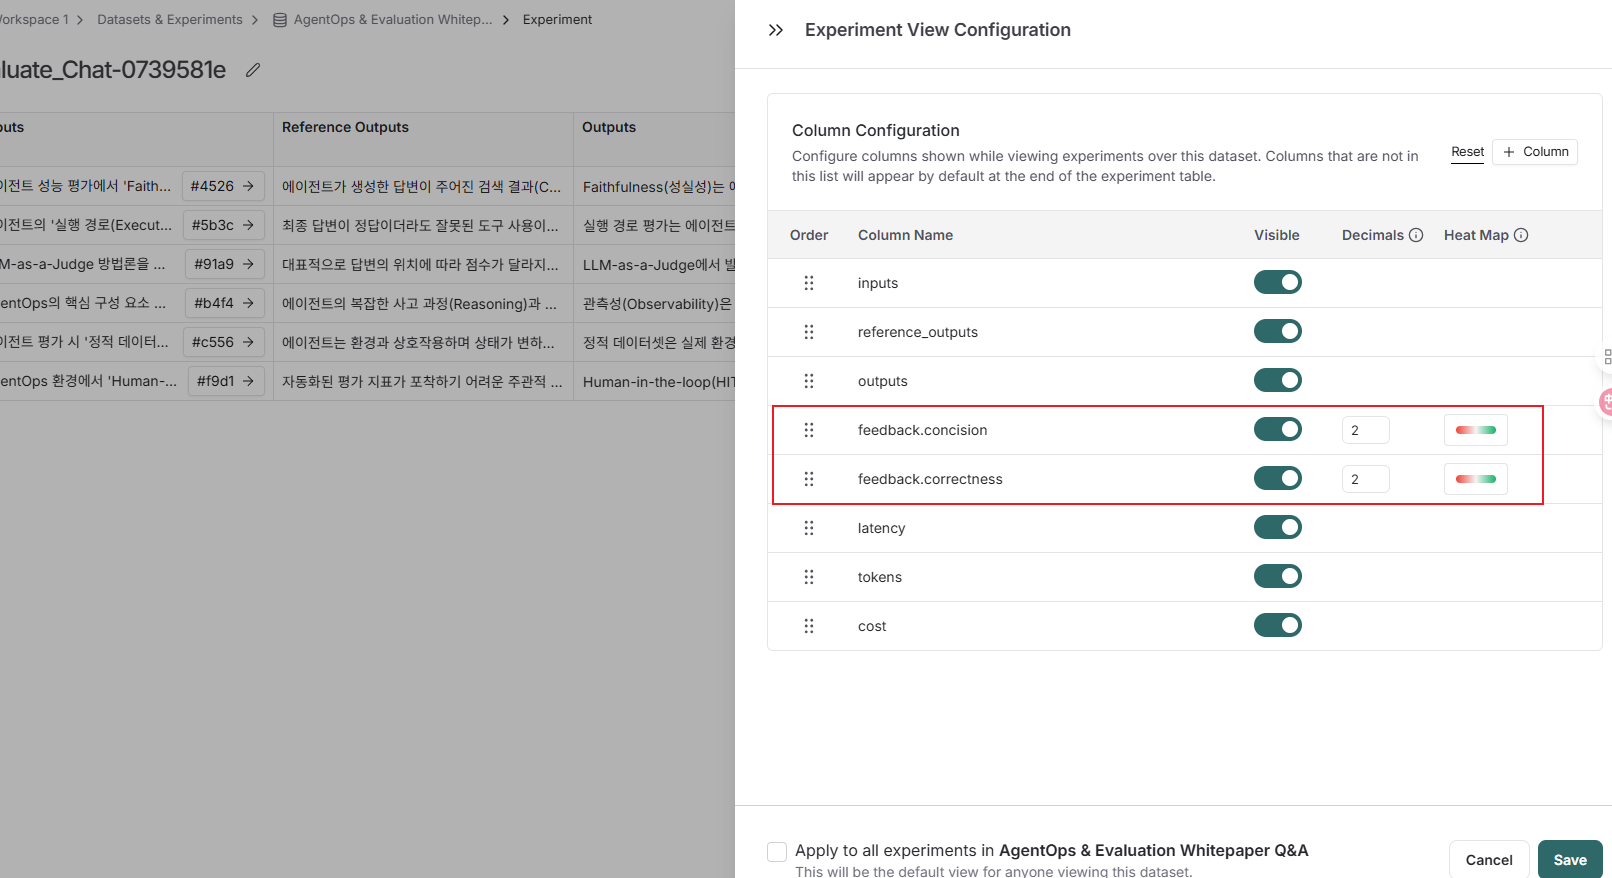

- concision과 correctness 의 visible을 끄고 Save를 누릅니다.

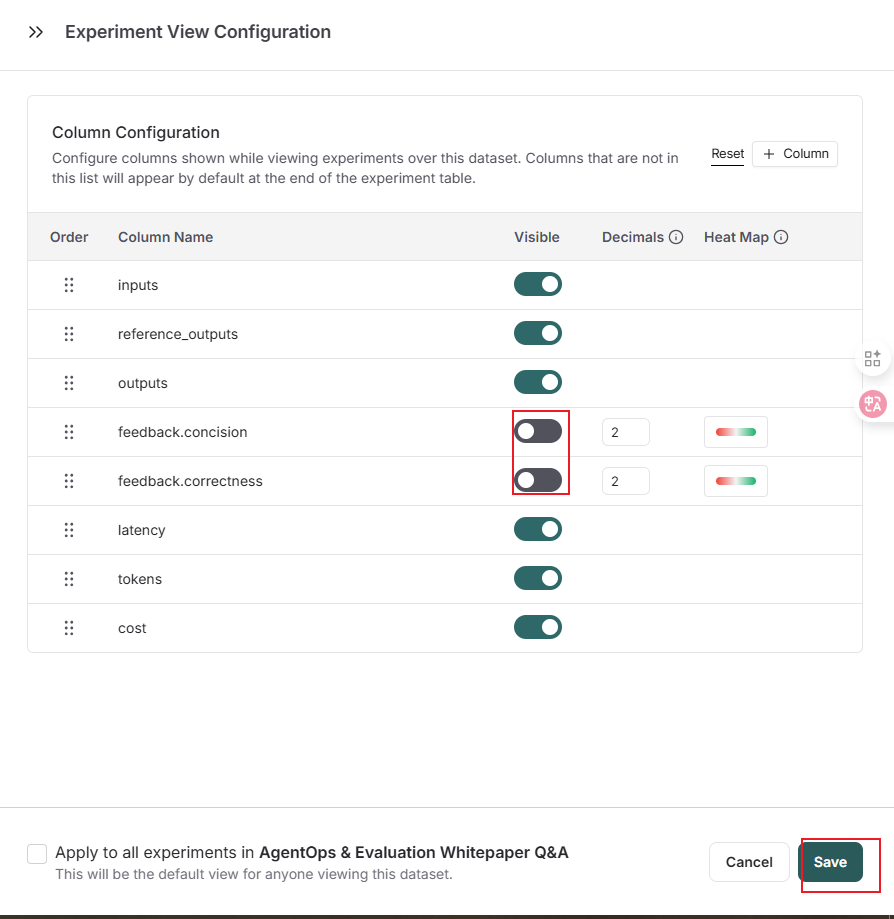

- 이후 다시 Display에 들어가서 visible을 켜주고 Save를 누릅니다.

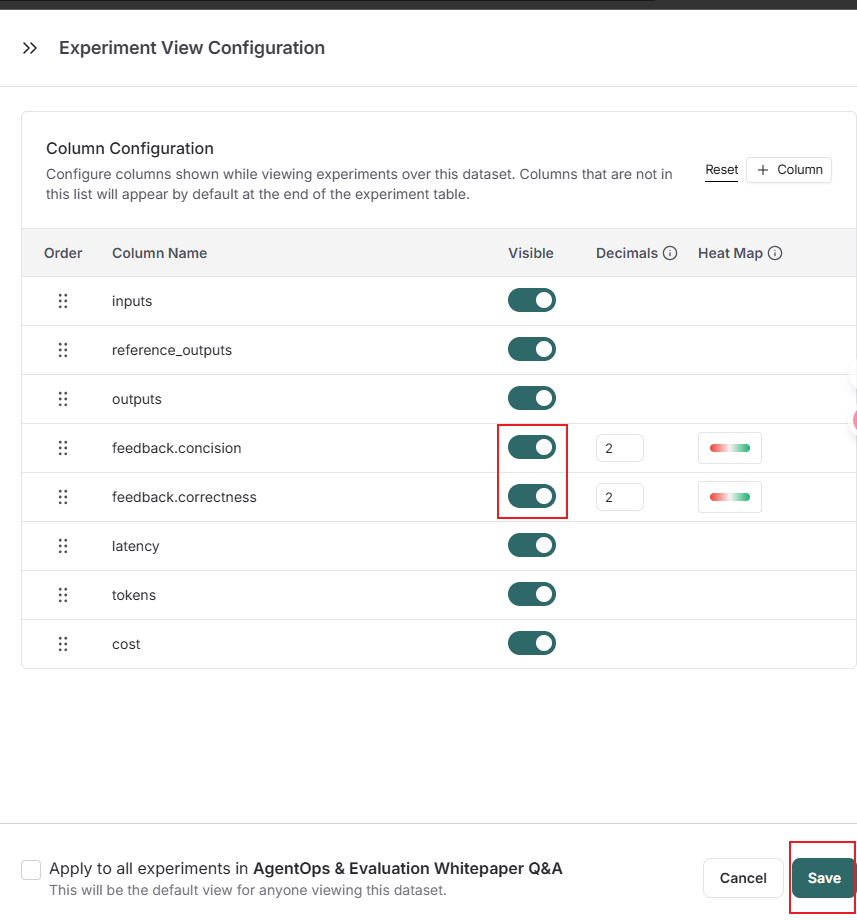

- 평가가 다시 보이는 것을 확인하실 수 있습니다.

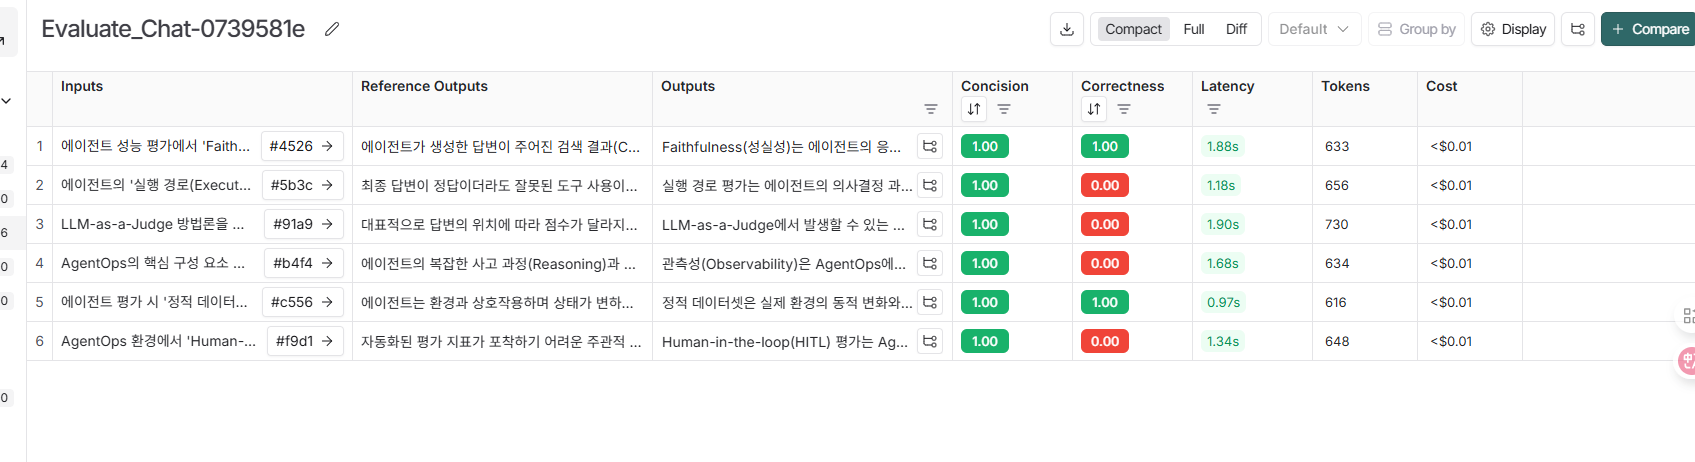

### Token 가격도 나오게 하려면

- Settings > Model > Add Model > 비용 입력

| model name | Prompt Price | Completion Price | Cached Input Price | Model Activation Date | Provider |
|---|---|---|---|---|---|
|solar-pro2 | \$0.15/MTok | \$0.6/MTok | \$0.015/MTok(cached)|2025-12-15| upstage |



- Settings 클릭

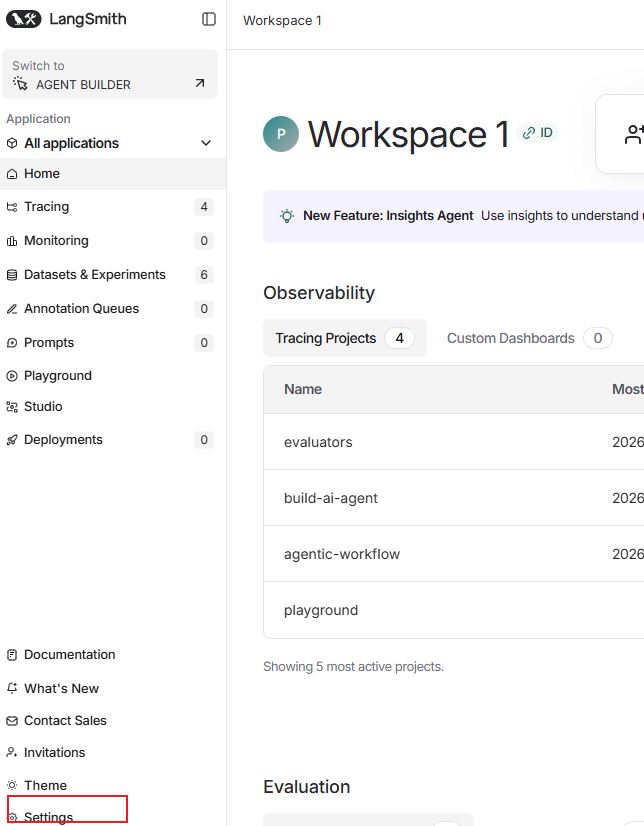

- 화면 상단의 Model Pricing 클릭

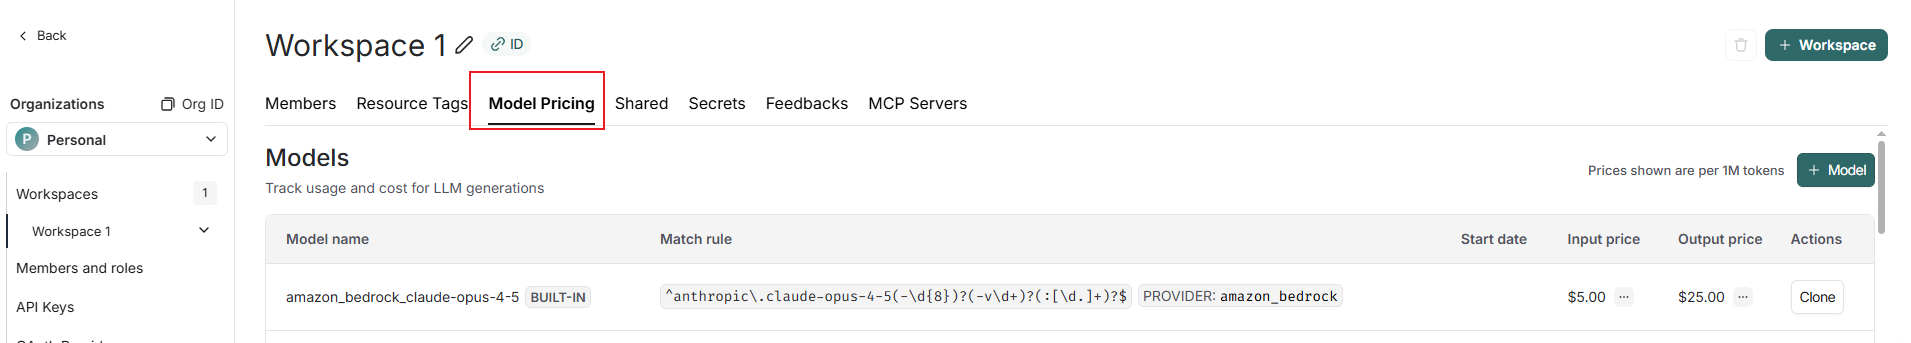

- `+ Model` 클릭

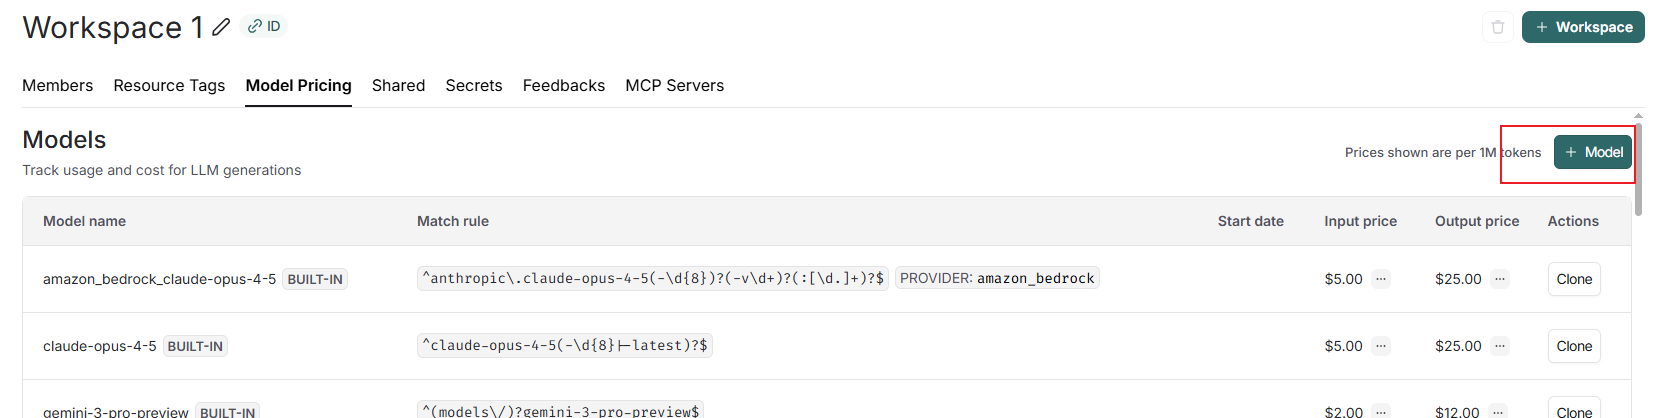

- solar-pro2 의 비용을 입력합니다.

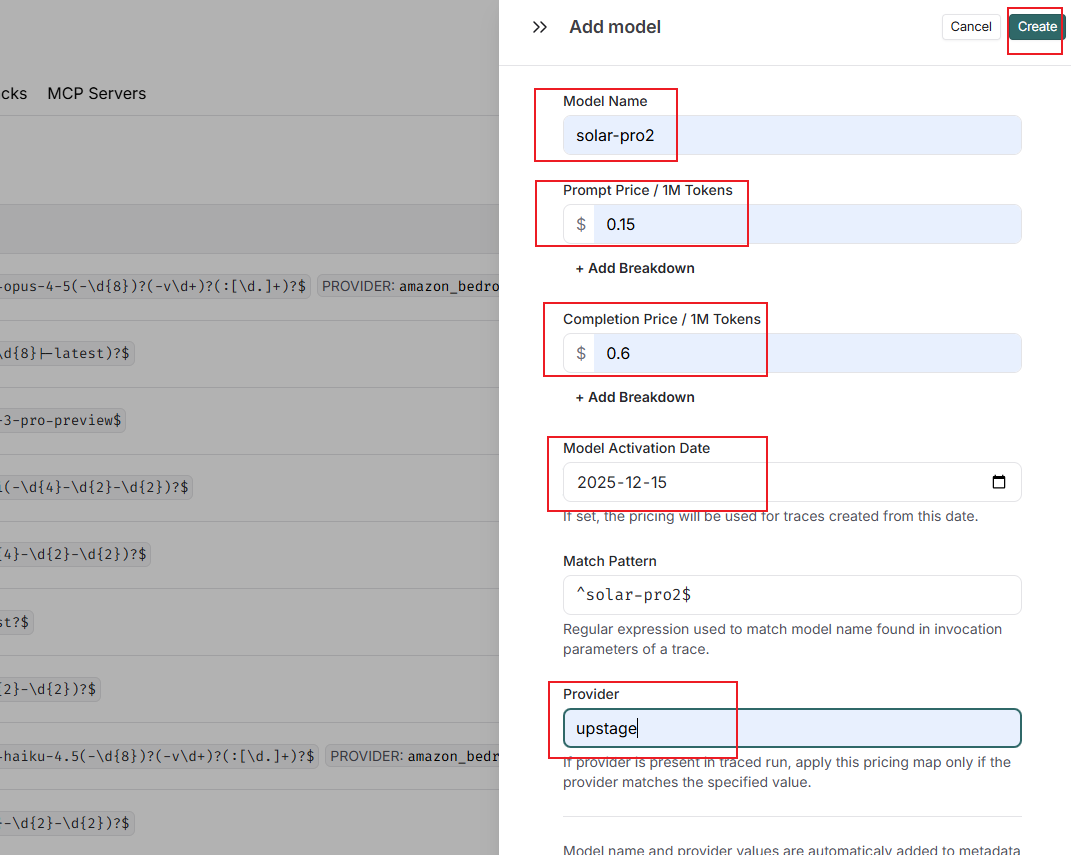

## Evaluate RAG
- 참고자료: https://docs.langchain.com/langsmith/evaluate-rag-tutorial

이전 5강 실습에서 다룬 RAG를 평가해보는 과정을 진행합니다.

In [9]:
# https://drive.google.com/file/d/1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y/view - d/ 와 /view 사이에 있는 아이디 값을 사용합니다.

!gdown --id 1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y -O Agents_Companion_v2.pdf

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y
To: /content/Agents_Companion_v2.pdf
100% 11.1M/11.1M [00:00<00:00, 28.7MB/s]


### RAG 구현 (이전 실습 자료 참고)
- 사용할 문서: [AgentOps & Eval에 관한 구글 백서](https://www.kaggle.com/whitepaper-agent-companion)

In [10]:
# ==============================
#            IMPORTS
# ==============================

from pydantic import BaseModel, Field, field_validator
from langchain.agents import create_agent
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict
from typing import Annotated, List, Literal
from langchain_core.documents import Document
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from langchain.chat_models import init_chat_model
from langchain_upstage import UpstageEmbeddings

# 함수 밖에서 클라이언트 변수를 미리 선언 (최초 1회만 생성하게 함)
_global_qdrant_client = None

/usr/local/lib/python3.12/dist-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
/usr/local/lib/python3.12/dist-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [11]:
# ==============================
#    Qdrant/Vectorstore SETUP
# ==============================

def load_and_split_pdf(file_path: str) -> List[Document]:
    """PDF를 로드하고 청크로 분할합니다."""
    from langchain_upstage import UpstageDocumentParseLoader
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    print(f"📄 PDF 로드 중: {file_path}")

    loader = UpstageDocumentParseLoader(
        file_path,
        output_format="markdown",
        ocr="force",
        coordinates=False
    )
    raw_pages = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        add_start_index=True,
    )
    splits = text_splitter.split_documents(raw_pages)
    print(f"✅ {len(splits)}개의 청크로 분할 완료")
    return splits


def setup_vectorstore(
    underlying_embeddings,
    collection_name,
    documents=None,
):
    """Qdrant 벡터스토어를 생성하고 채웁니다."""
    global _global_qdrant_client

    if _global_qdrant_client is None:
        _global_qdrant_client = QdrantClient(path="./qdrant_db")

    qdrant_client = _global_qdrant_client

    # 캐시 스토어 생성
    store = LocalFileStore("./cache/")

    # CacheBackedEmbeddings로 감싸서 캐싱 활성화
    # 여러번 시행할 경우 캐시 활용 (비용 절약)
    embeddings = CacheBackedEmbeddings.from_bytes_store(
        underlying_embeddings,
        store,
        namespace=underlying_embeddings.model,
    )

    # 컬렉션이 이미 존재하는지 확인
    if not qdrant_client.collection_exists(collection_name):
        print(f"📦 새로운 컬렉션 생성 중: {collection_name}")
        _global_qdrant_client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(
                size=4096,
                distance=Distance.COSINE),
        )

    # VectorStore
    vectorstore = QdrantVectorStore(
        client=qdrant_client,
        collection_name=collection_name,
        embedding=embeddings,
    )

    # documents가 제공된 경우에만 추가
    if documents:
        vectorstore.add_documents(documents)
        print(f"✅ {len(documents)}개의 문서가 추가되었습니다.")
    else:
        print(f"ℹ️ 기존 벡터스토어를 로드했습니다 (추가 문서 없음).")

    return vectorstore

def get_or_create_vectorstore(
    underlying_embeddings,
    collection_name: str,
    pdf_path: str = "Agents_Companion_v2.pdf"
):
    """벡터스토어를 가져오거나 생성합니다. 문서가 없으면 PDF를 로드합니다."""
    global _global_qdrant_client

    if _global_qdrant_client is None:
        print("🚀 Qdrant 클라이언트를 새로 초기화합니다.")
        _global_qdrant_client = QdrantClient(path="./qdrant_db")

    # 문서가 필요한지 확인
    doc_splits = None

    if _global_qdrant_client.collection_exists(collection_name):
        points_count = _global_qdrant_client.get_collection(collection_name).points_count
        if points_count == 0:
            print("📭 컬렉션이 비어있습니다. PDF를 로드합니다...")
            doc_splits = load_and_split_pdf(pdf_path)
        else:
            print(f"✅ 기존 벡터스토어 사용 ({points_count}개 문서)")
    else:
        print("🆕 새 컬렉션을 생성합니다. PDF를 로드합니다...")
        doc_splits = load_and_split_pdf(pdf_path)

    return setup_vectorstore(
        underlying_embeddings=underlying_embeddings,
        collection_name=collection_name,
        documents=doc_splits
    )

In [12]:
# ==============================
#     임베딩/벡터스토어 준비
# ==============================
underlying_embeddings = UpstageEmbeddings(
    model="solar-embedding-1-large"
)

vectorstore = get_or_create_vectorstore(
    underlying_embeddings=underlying_embeddings,
    collection_name="solar-embedding-1-large",
    pdf_path="Agents_Companion_v2.pdf"
)

🚀 Qdrant 클라이언트를 새로 초기화합니다.
🆕 새 컬렉션을 생성합니다. PDF를 로드합니다...
📄 PDF 로드 중: Agents_Companion_v2.pdf
✅ 134개의 청크로 분할 완료
📦 새로운 컬렉션 생성 중: solar-embedding-1-large


/usr/local/lib/python3.12/dist-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


✅ 134개의 문서가 추가되었습니다.


In [13]:
# ==============================
#     Build RAG
# ==============================
class State(TypedDict):
    user_query: str                             # 사용자 질문
    query_embedding: str                        # 쿼리 임베딩 벡터 (질문 임베딩)
    retrieved_documents: List[Document]         # 검색된 Chunk 리스트
    generated_answer: str                       # LLM이 생성한 답변

def query_vectorization(state: State) -> State:
    query_embedding = underlying_embeddings.embed_query(state['user_query'])
    return {"query_embedding": query_embedding}

def retriever(state: State) -> State:
    results = vectorstore.similarity_search_by_vector(state['query_embedding'], k=5)
    return {"retrieved_documents": results}

def generater(state: State) -> State:
    prompt = f"""
    다음 문서를 참고하여 질문에 답하세요.

    문서:
    {state['retrieved_documents']}

    질문:
    {state['user_query']}
    """
    response = llm.invoke(prompt)
    return {"generated_answer": response}

rag_workflow = StateGraph(State)

rag_workflow.add_node("query_vectorization", query_vectorization)
rag_workflow.add_node("retriever", retriever)
rag_workflow.add_node("generater", generater)

rag_workflow.add_edge(START, "query_vectorization")
rag_workflow.add_edge("query_vectorization", "retriever")
rag_workflow.add_edge("retriever", "generater")
rag_workflow.add_edge("generater", END)

rag_workflow = rag_workflow.compile()

### Dataset

In [14]:
from langsmith import Client

client = Client()

# AgentOps 및 Agent Evaluation 방법론 기반 테스트 케이스
examples = [
    {
        "inputs": {"question": "AgentOps의 핵심 구성 요소 중 '관측성(Observability)'이 중요한 이유는 무엇인가요?"},
        "outputs": {"answer": "에이전트의 복잡한 사고 과정(Reasoning)과 도구 호출(Tool Calling) 과정을 추적(Tracing)하여 병목 현상을 진단하고, 모델의 환각(Hallucination)이 발생하는 정확한 시점을 파악하기 위해 필수적입니다."}
    },
    {
        "inputs": {"question": "LLM-as-a-Judge 방법론을 사용할 때 발생할 수 있는 'LLM 바이어스'의 종류는 무엇인가요?"},
        "outputs": {"answer": "대표적으로 답변의 위치에 따라 점수가 달라지는 위치 바이어스(Position bias), 답변이 길수록 높은 점수를 주는 길이 바이어스(Verbosity bias), 그리고 특정 모델의 스타일을 선호하는 자아 중심적 바이어스(Self-enhancement bias)가 있습니다."}
    },
    {
        "inputs": {"question": "에이전트 성능 평가에서 'Faithfulness(성실성)' 지표는 무엇을 측정하나요?"},
        "outputs": {"answer": "에이전트가 생성한 답변이 주어진 검색 결과(Context) 내의 정보만을 바탕으로 작성되었는지, 즉 외부 지식을 섞거나 임의로 내용을 지어내지 않았는지를 측정합니다."}
    },
    {
        "inputs": {"question": "AgentOps 환경에서 'Human-in-the-loop(HITL)' 평가의 역할은 무엇인가요?"},
        "outputs": {"answer": "자동화된 평가 지표가 포착하기 어려운 주관적 품질(톤, 매너, 안전성)을 검증하고, 모델이 생성한 데이터의 레이블을 교정하여 더 정교한 자동 평가기를 학습시키는 기준(Ground Truth)을 제공합니다."}
    },
    {
        "inputs": {"question": "에이전트의 '실행 경로(Execution Path)' 평가가 단순 결과값 평가보다 중요한 이유는 무엇인가요?"},
        "outputs": {"answer": "최종 답변이 정답이더라도 잘못된 도구 사용이나 비효율적인 추론 과정을 거쳤을 경우, 실제 운영 환경에서 높은 비용과 지연 시간을 초래할 수 있기 때문에 전체 워크플로우의 효율성을 함께 평가해야 합니다."}
    },
    {
        "inputs": {"question": "에이전트 평가 시 '정적 데이터셋'만으로 부족한 이유는 무엇인가요?"},
        "outputs": {"answer": "에이전트는 환경과 상호작용하며 상태가 변하는 동적인 특성을 가지므로, 고정된 질의응답 외에도 다양한 도구 호출 시나리오와 예외 상황에 대한 '시뮬레이션 기반 평가'가 병행되어야 합니다."}
    }
]

# 데이터셋 생성 및 업로드
dataset_name = "AgentOps & Evaluation Whitepaper Q&A"

# 기존에 동일한 이름의 데이터셋이 있는지 확인 후 생성
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name, description="Google 백서 기반 AgentOps 및 평가 방법론 데이터셋")
    client.create_examples(
        dataset_id=dataset.id,
        examples=examples
    )
    print(f"✅ 데이터셋 '{dataset_name}' 생성이 완료되었습니다.")
else:
    print(f"ℹ️ '{dataset_name}' 데이터셋이 이미 존재합니다.")

ℹ️ 'AgentOps & Evaluation Whitepaper Q&A' 데이터셋이 이미 존재합니다.


### Define Metrics

- Correctness: Response vs reference answer

In [15]:
from pydantic import BaseModel, Field
from typing import Annotated

# 1. 구조화된 출력 스키마 정의
class CorrectnessGrade(BaseModel):
    """학생의 답변에 대한 채점 결과와 논리적 근거입니다."""
    explanation: str = Field(description="채점 결과에 대한 단계별 논리적 근거")
    correct: bool = Field(description="학생의 답변이 사실적으로 정확하면 True, 틀리면 False")

# 2. 채점 가이드라인
correctness_instructions = """You are a teacher grading a quiz.
You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.

Grade criteria:
(1) Grade based ONLY on factual accuracy relative to the ground truth.
(2) Ensure no conflicting statements.
(3) More information is OK if factually accurate.

Step-by-step reasoning is required before concluding."""

# 3. 채점 함수 수정
def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """RAG 답변 정확도 평가기"""

    # Solar 모델에 구조화된 출력 설정
    structured_grader = llm.with_structured_output(CorrectnessGrade)

    answers = f"""
QUESTION: {inputs['question']}
GROUND TRUTH ANSWER: {reference_outputs['answer']}
STUDENT ANSWER: {outputs['answer']}
"""

    # 모델 호출
    grade = structured_grader.invoke([
        {"role": "system", "content": correctness_instructions},
        {"role": "user", "content": answers}
    ])

    # 결과 반환
    return grade.correct

- Relevance: Response vs input

In [16]:
from pydantic import BaseModel, Field

# 1. 구조화된 출력 스키마 정의
class RelevanceGrade(BaseModel):
    """답변의 질문 관련성 및 유용성에 대한 채점 결과입니다."""
    explanation: str = Field(description="답변이 질문에 얼마나 관련 있고 유용한지에 대한 단계별 논리적 근거")
    relevant: bool = Field(description="답변이 질문을 해결하는 데 도움이 되고 관련이 있으면 True, 아니면 False")

# 2. 채점 가이드라인
relevance_instructions = """You are a teacher grading a quiz.
You will be given a QUESTION and a STUDENT ANSWER.

Grade criteria:
(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION.
(2) Ensure the STUDENT ANSWER helps to answer the QUESTION.

Step-by-step reasoning is required before concluding."""

# 3. 채점 함수
def relevance(inputs: dict, outputs: dict, reference_outputs: dict = None) -> bool:
    """RAG 답변의 질문 관련성 및 유용성 평가기"""

    # Solar 모델에 구조화된 출력 설정
    structured_grader = llm.with_structured_output(RelevanceGrade)

    answer_content = f"QUESTION: {inputs['question']}\nSTUDENT ANSWER: {outputs['answer']}"

    # 모델 호출
    grade = structured_grader.invoke([
        {"role": "system", "content": relevance_instructions},
        {"role": "user", "content": answer_content}
    ])

    # 결과 반환 (Pydantic 객체이므로 .relevant로 접근)
    return grade.relevant

- Groundedness: Response vs retrieved docs

In [17]:
from pydantic import BaseModel, Field

# 1. 구조화된 출력 스키마 정의
class GroundedGrade(BaseModel):
    """답변이 검색된 문서(FACTS)에 기반하고 있는지에 대한 채점 결과입니다."""
    explanation: str = Field(description="답변이 주어진 사실(FACTS)에 근거하는지에 대한 단계별 논리적 근거")
    grounded: bool = Field(description="답변이 문서에 없는 내용을 지어내지(환각) 않고 근거가 확실하면 True, 아니면 False")

# 2. 채점 가이드라인
grounded_instructions = """You are a teacher grading a quiz.
You will be given FACTS and a STUDENT ANSWER.

Grade criteria:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS.
(2) Ensure the STUDENT ANSWER does not contain "hallucinated" information outside the scope of the FACTS.

Step-by-step reasoning is required before concluding."""

# 3. 채점 함수
def groundedness(inputs: dict, outputs: dict, reference_outputs: dict = None) -> bool:
    """RAG 답변의 근거성(환각 여부) 평가기"""

    # Solar 모델에 구조화된 출력 설정
    structured_grader = llm.with_structured_output(GroundedGrade)

    # 애플리케이션 결과에서 검색된 문서들을 추출 (AppOutput에 documents 필드가 있다고 가정)
    # 만약 documents가 리스트라면 내용을 합쳐줍니다.
    docs = outputs.get("documents", [])
    if isinstance(docs, list):
        doc_string = "\n\n".join(doc.page_content if hasattr(doc, 'page_content') else str(doc) for doc in docs)
    else:
        doc_string = str(docs)

    answer_content = f"FACTS: {doc_string}\nSTUDENT ANSWER: {outputs['answer']}"

    # 모델 호출
    grade = structured_grader.invoke([
        {"role": "system", "content": grounded_instructions},
        {"role": "user", "content": answer_content}
    ])

    # 결과 반환 (Pydantic 객체이므로 .grounded로 접근)
    return grade.grounded

- Retrieval relevance: Retrieved docs vs input

In [18]:
from pydantic import BaseModel, Field

# 1. 구조화된 출력 스키마 정의
class RetrievalRelevanceGrade(BaseModel):
    """검색된 문서들이 질문과 관련이 있는지에 대한 채점 결과입니다."""
    explanation: str = Field(description="검색된 문서들이 질문과 어떤 의미적 연관성이 있는지에 대한 단계별 논리적 근거")
    relevant: bool = Field(description="문서들 중에 질문과 관련된 키워드나 의미가 조금이라도 포함되어 있으면 True, 전혀 관련 없으면 False")

# 2. 채점 가이드라인
retrieval_relevance_instructions = """You are a teacher grading a quiz.
You will be given a QUESTION and a set of FACTS (retrieved documents).

Grade criteria:
(1) Identify if the FACTS contain information related to the QUESTION.
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant.
(3) It is OK if the facts have SOME information that is unrelated to the question as long as (2) is met.

Step-by-step reasoning is required before concluding."""

# 3. 채점 함수
def retrieval_relevance(inputs: dict, outputs: dict, reference_outputs: dict = None) -> bool:
    """검색된 문서의 관련성 평가기 (Retriever 성능 평가)"""

    # Solar 모델에 구조화된 출력 설정
    structured_grader = llm.with_structured_output(RetrievalRelevanceGrade)

    # 검색된 문서들을 문자열로 합치기
    docs = outputs.get("documents", [])
    if isinstance(docs, list):
        doc_string = "\n\n".join(doc.page_content if hasattr(doc, 'page_content') else str(doc) for doc in docs)
    else:
        doc_string = str(docs)

    answer_content = f"FACTS: {doc_string}\nQUESTION: {inputs['question']}"

    # 모델 호출
    grade = structured_grader.invoke([
        {"role": "system", "content": retrieval_relevance_instructions},
        {"role": "user", "content": answer_content}
    ])

    # 결과 반환 (Pydantic 객체이므로 .relevant로 접근)
    return grade.relevant

### Run Evaluator

In [19]:
from pydantic import BaseModel, Field

class AppOutput(BaseModel):
    answer: str = Field(description="사용자의 질문에 대한 최종 답변")
    reasoning: str = Field(description="답변을 도출한 사고 과정")
    documents: list = Field(default=[], description="검색된 문서 리스트")

def my_app(question: str) -> AppOutput:
    structured_llm = llm.with_structured_output(AppOutput)

    instructions = "Based on the retrieved documents, kindly answer the question."

    # 모델 호출
    response = structured_llm.invoke([
        {"role": "system", "content": instructions},
        {"role": "user", "content": question},
    ])
    return response

In [20]:
# 1. 평가 대상 함수 (Target)
def target(inputs: dict) -> dict:
    # 데이터셋의 "question"을 워크플로우의 입력인 "user_query"로 전달합니다.
    result = rag_workflow.invoke({"user_query": inputs["question"]})

    # 2. 평가기가 기대하는 키(answer, documents)로 매핑
    raw_answer = result.get("generated_answer", "")
    if isinstance(raw_answer, dict):
        final_answer = raw_answer.get("generated_answer", "")
    else:
        final_answer = raw_answer

    return {
        "answer": final_answer,                    # correctness, relevance
        "documents": result.get("retrieved_documents", [])  # groundedness, retrieval_relevance
    }

experiment_results = client.evaluate(
    target,
    data=dataset_name,
    # 앞서 정의한 4가지 핵심 평가기 투입
    evaluators=[
        correctness,
        groundedness,
        relevance,
        retrieval_relevance
    ],
    experiment_prefix="solar-rag-comprehensive-eval",
    # 메타데이터에 현재 실험 환경을 상세히 기록
    metadata={
        "variant": "Upstage Solar-Pro with RAG",
        "model": "solar-pro2",
        "embedding": "solar-embedding-1-large",
        "evaluator_model": "solar-pro2"
    },
)

# 3. 결과 확인
# import pandas as pd
# df = experiment_results.to_pandas()
# display(df)

View the evaluation results for experiment: 'solar-rag-comprehensive-eval-220d05b2' at:
https://smith.langchain.com/o/7eb12019-fc22-4cd9-8caf-766b99514a6f/datasets/5f7326d1-892f-4ba8-8d43-c2c8ff960416/compare?selectedSessions=b5d6206f-ddd7-465a-bea0-70163ee6b011




0it [00:00, ?it/s]